# Fraud Detection Case Study

## AI Usage Disclosure

AI Was used to check syntax and write code based on my instructions (i.e. write code for 60|20|20 train|val|test split (temporal split using column "step")). Also used AI to generate the requirements.txt for me.

## Assumptions

- Need real time inference as transactions occur because the point is to stop a transaction if it is suspected of being fraudulent rather than let it pass and attempt to recover later (assumed to be more costly to recover)
- Manual review will be done in batches (i.e. end of day or receive batch from previous day at beginning of current day). Alternatively, if < 1000 are flagged each day, this won't even be an issue. Can be sent live as model flags. This is something to confirm with stakeholders.
- Under these assumptions, I will be dropping newbalanceOrig and newbalanceDest since these contain information only known after the transaction, and if a transaction is flagged as fraud and prevented, we wouldn't know the new balance at the time we need to make the decision.

In [1]:
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## EDA

In [2]:
# Read in file and describe data frame
df = pd.read_csv("data/Fraud.csv")
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [3]:
df.rename(columns={"oldbalanceOrg": "oldbalanceOrig"}, inplace=True) #gonna rename this for consistency

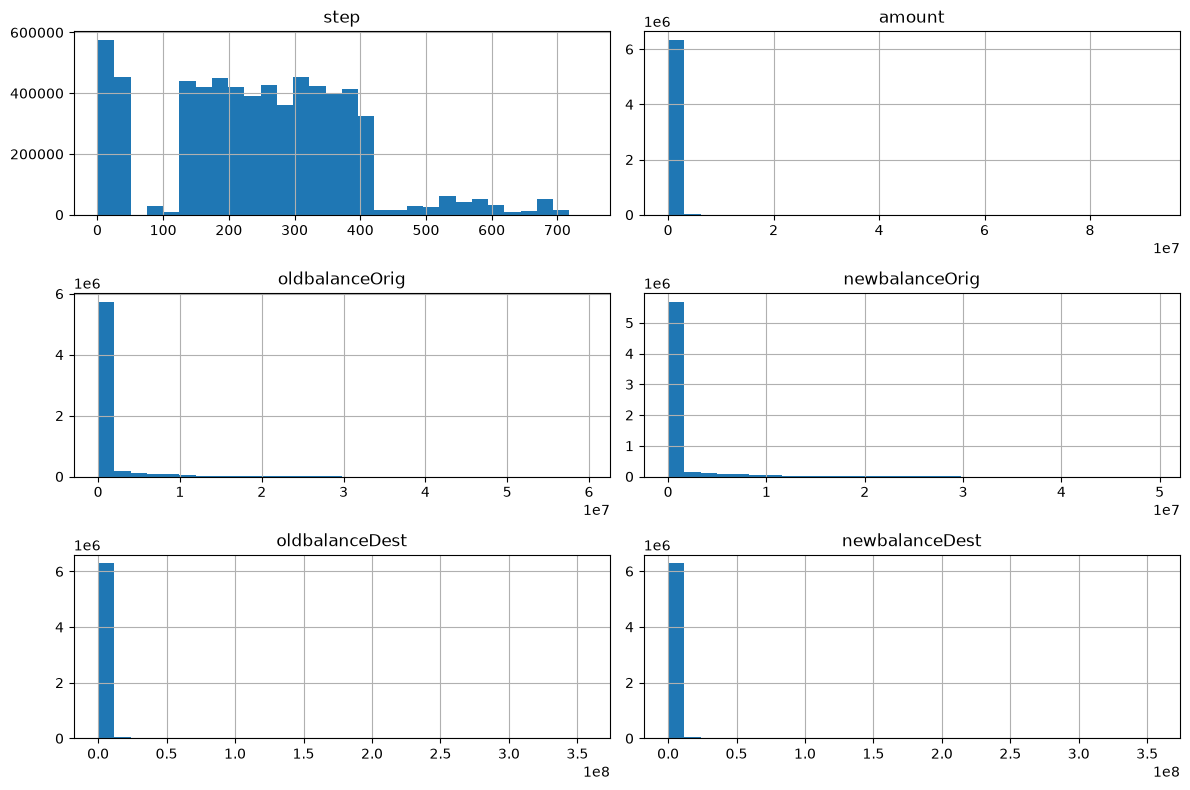

In [4]:
# Histogram of numerical features
cols = ["step", "amount", "oldbalanceOrig", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]

df[cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()


Most of the numerical variables have a long right tail, so we should apply scaling after splitting (for logreg baseline model).

In [5]:
# Check distribution of isFraud and isFlaggedFraud
for col in ["isFraud", "isFlaggedFraud"]:
    print(f"\n{col}")
    print(
        df.groupby(col)
          .agg(
              count=("amount", "size"),
              total_amount_millions=("amount", lambda x: x.sum() / 1_000_000)
          )
          .assign(
              pct=lambda x: x["count"] / x["count"].sum() * 100,
              amount_pct=lambda x: x["total_amount_millions"] / x["total_amount_millions"].sum() * 100
          )
          .round(2)
    )


isFraud
           count  total_amount_millions    pct  amount_pct
isFraud                                                   
0        6354407             1132336.53  99.87       98.95
1           8213               12056.42   0.13        1.05

isFlaggedFraud
                  count  total_amount_millions    pct  amount_pct
isFlaggedFraud                                                   
0               6362604             1144315.16  100.0       99.99
1                    16                  77.79    0.0        0.01


We can see that 0.13% of instances are fraud, but the hard-coded rule is only flagging 0.01%, leaving a lot of money on the table.

Now, let's check fraud rate by Type.

In [19]:
fraud_by_type = (
    df.groupby("type")
      .agg(
          transaction_count=("isFraud", "size"),
          fraud_count=("isFraud", "sum"),
          fraud_rate=("isFraud", "mean")
      )
      .sort_values("fraud_rate", ascending=False)
)

display(
    fraud_by_type.style.format({
        "transaction_count": "{:,.0f}",
        "fraud_count": "{:,.0f}",
        "fraud_rate": "{:.3%}"
    })
)


,transaction_count,fraud_count,fraud_rate
type,,,
TRANSFER,"532,909","4,097",0.769%
CASH_OUT,"2,237,500","4,116",0.184%
CASH_IN,"1,399,284",0,0.000%
DEBIT,"41,432",0,0.000%
PAYMENT,"2,151,495",0,0.000%


We can see fraud rate is highest for TRANSFER, and it only seems to happen for TRANSFER and CASH_OUT.

Let's check the fraud date over time with 24 hr windows as approximates for day.

,transaction_count,fraud_count,fraud_rate
day_window,,,
1,"574,255",271,0.047%
2,"455,238",309,0.068%
3,"1,070",310,28.972%
4,"28,240",262,0.928%
5,"9,789",252,2.574%
6,"441,005",228,0.052%
7,"420,583",272,0.065%
8,"449,637",278,0.062%
9,"417,919",255,0.061%


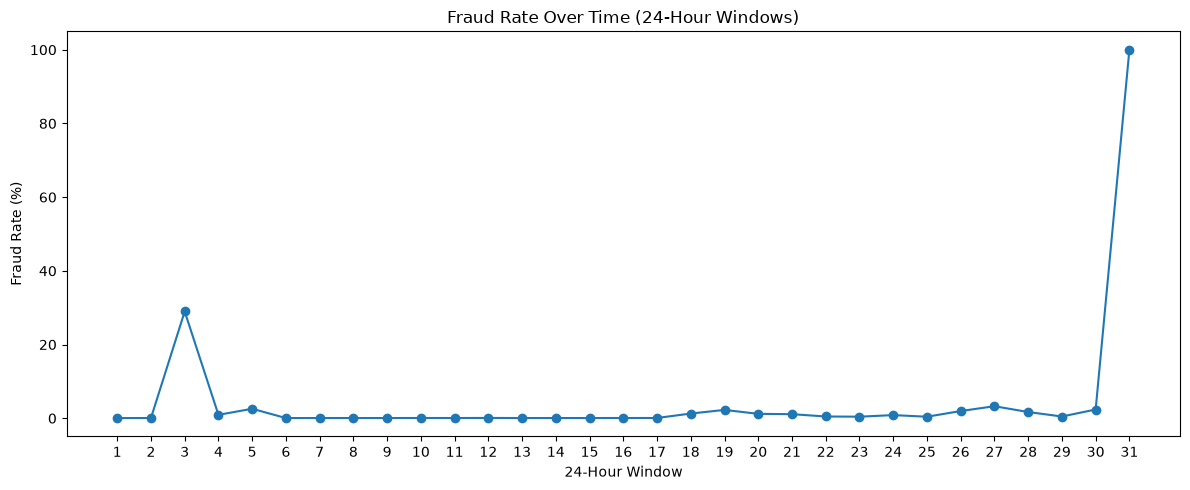

In [7]:
# Group step into consecutive 24-hour windows
df["day_window"] = (df["step"] - 1) // 24 + 1

fraud_by_day = (
    df.groupby("day_window")
      .agg(
          transaction_count=("isFraud", "size"),
          fraud_count=("isFraud", "sum"),
          fraud_rate=("isFraud", "mean")
      )
      .sort_index()
)

display(
    fraud_by_day.style.format({
        "transaction_count": "{:,.0f}",
        "fraud_count": "{:,.0f}",
        "fraud_rate": "{:.3%}"
    })
)

# Plot daily-window fraud rate
ax = fraud_by_day["fraud_rate"].mul(100).plot(
    kind="line",
    marker="o",
    figsize=(12, 5)
)
ax.set_title("Fraud Rate Over Time (24-Hour Windows)")
ax.set_xlabel("24-Hour Window")
ax.set_ylabel("Fraud Rate (%)")
ax.set_xticks(fraud_by_day.index)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In the last 24 hours window, there seems to be an upstream data pipeline issue (100% fraud rate; non-fraudulent transactions not making it into the pipeline?). There's also a spike in Day 3. Making a note of this for now, but in a real-life scenario, would be worth investigating. Since we are doing temporal split later, the day 31 spike in fraud rate could make our test metrics look inflated.

## Feature Engineering

In [8]:
# add some engineered features

# check if trying to transfer money from a 0 balance account
df["orig_balance_zero"] = (df["oldbalanceOrig"] == 0).astype(int) 

# check if trying to transfer money to a 0 balance account
df["dest_balance_zero"] = (df["oldbalanceDest"] == 0).astype(int) 

# check if trying to transfer an amount that exceeds what's in the account
df["exceeds_balance"] = (df["oldbalanceOrig"] < df["amount"]).astype(int) 

# how large is the transfer amount relative to the original balance
# this feature resulted in 1.0 PR AUC, precision, and recall when using Random Forest. Leaving out for now due to time constraint. I would put this back only after confirming this does not result in leakage.
#df["amount_to_oldbalanceOrig"] = (
#    df["amount"] / df["oldbalanceOrig"].replace(0, np.nan)
#)

#df["amount_to_oldbalanceOrig"] = df["amount_to_oldbalanceOrig"].fillna(0)


## Train/Test Split

In [9]:
# train/val/test split: since we have plenty of data, we can split 60|20|20 and use temporal split since we want to predict future fraud
steps = sorted(df["step"].unique())

n = len(steps)
train_cutoff = steps[int(n * 0.6)]
val_cutoff = steps[int(n * 0.8)]

train_df = df[df["step"] < train_cutoff]
val_df = df[
    (df["step"] >= train_cutoff) &
    (df["step"] < val_cutoff)
]
test_df = df[df["step"] >= val_cutoff]

#The instructions say that newbalanceOrig and newbalanceDest are information after the transaction. 
#Since I don't have additional context, I will assume that we are trying to create a system that flags 
#fraud before the transaction goes through, in which case these 2 features will contain information that will not be available.
ex_cols = ["isFraud", "nameOrig", "nameDest", "isFlaggedFraud", "newbalanceDest", "newbalanceOrig", "step", "day_window"] #columns to exclude from training

X_train = train_df.drop(columns=ex_cols)
y_train = train_df["isFraud"]

X_val = val_df.drop(columns=ex_cols)
y_val = val_df["isFraud"]

X_test = test_df.drop(columns=ex_cols)
y_test = test_df["isFraud"]

print(X_train.shape, X_val.shape, X_test.shape)
print(X_train.columns) #check to make sure the columns are the ones we want

(6010937, 7) (228103, 7) (123580, 7)
Index(['type', 'amount', 'oldbalanceOrig', 'oldbalanceDest',
       'orig_balance_zero', 'dest_balance_zero', 'exceeds_balance'],
      dtype='str')


## OHE for categorical; impute missing values with median for numerical

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

num_cols = ['amount', 'oldbalanceOrig', #'newbalanceOrig',
       'oldbalanceDest', #'newbalanceDest', 
        'orig_balance_zero', 'dest_balance_zero', 'exceeds_balance'] #'amount_to_oldbalanceOrig']
cat_cols = ['type']


# impute missing vals
medians = X_train[num_cols].median()

X_train[num_cols] = X_train[num_cols].fillna(medians)
X_val[num_cols] = X_val[num_cols].fillna(medians)
X_test[num_cols] = X_test[num_cols].fillna(medians)

# OHE categorical
X_train = pd.get_dummies(X_train, columns=cat_cols, dtype=int)
X_val = pd.get_dummies(X_val, columns=cat_cols, dtype=int)
X_test = pd.get_dummies(X_test, columns=cat_cols, dtype=int)

# Match the training columns exactly
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


In [11]:
# Scale numerical
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## Baseline model: Logistic Regression

In [12]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to u

Performance evaluation using PR-AUC (due to class imbalance), precision, and recall

In [13]:
from sklearn.metrics import average_precision_score, precision_score, recall_score

# Predict on validation set
y_val_proba = model.predict_proba(X_val_scaled)[:, 1]
y_val_pred = model.predict(X_val_scaled)

print("PR-AUC:", average_precision_score(y_val, y_val_proba))
print("Precision:", precision_score(y_val, y_val_pred, zero_division=0))
print("Recall:", recall_score(y_val, y_val_pred, zero_division=0))

PR-AUC: 0.7149352484261889
Precision: 0.13411785065328372
Recall: 0.9987113402061856


## Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, precision_score, recall_score

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Evaluate on validation set
y_val_proba_rf = rf.predict_proba(X_val)[:, 1]
y_val_pred_rf = (y_val_proba_rf >= 0.5).astype(int)

print("PR-AUC:", average_precision_score(y_val, y_val_proba_rf))
print("Precision:", precision_score(y_val, y_val_pred_rf, zero_division=0))
print("Recall:", recall_score(y_val, y_val_pred_rf, zero_division=0))

PR-AUC: 0.9784437066703588
Precision: 0.9707865168539326
Recall: 0.8350515463917526


## Hyperparameter Tuning
I initially tried using random search for hyperparameter tuning, but due to the size of the data and limited computing power, it was taking too long for the results to come back. I tried to increase n_estimators a bit, and it once again hung/kernel died. Assuming there is a time constraint and that I need to provide an update to the fraud operations lead soon, the model performance we have so far is already significantly better than the manual rule and sufficient for a first update. If I had more time, I would tune the model for optimal hyperparameters and look at other models such as XGBoost, but given current constraints, it may make more sense to proceed with what we have and save other updates for a V2.

## Test with unseen data

In [15]:
# Check test size
print(X_test.shape)

(123580, 11)


Confusion Matrix:
[[121901     25]
 [   262   1392]]

Test Average Precision: 0.9842306776690246

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    121926
           1       0.98      0.84      0.91      1654

    accuracy                           1.00    123580
   macro avg       0.99      0.92      0.95    123580
weighted avg       1.00      1.00      1.00    123580



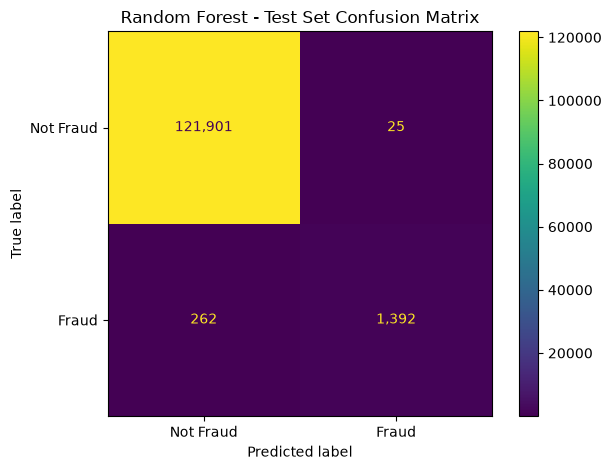

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Predict on the test set
y_test_proba = rf.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

print("\nTest Average Precision:", average_precision_score(
    y_test, y_test_proba
))

print("\nClassification Report:")
print(classification_report(
    y_test, y_test_pred, zero_division=0
))

# Visualize the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Fraud", "Fraud"]
)
disp.plot(values_format=",d")
plt.title("Random Forest - Test Set Confusion Matrix")
plt.tight_layout()
plt.show()


Since we have a hard constraint of 1000 manual reviews, I propose sending the top 1000 highest-risk transactions for review. Also, since not all transactions are the same amount, let's include some $ in the summary.

We should also compare the Hardcoded Rule vs my proposed workflow. The test set represents ~5 days (if we don't count the last 24 hours) of data, so at a daily limit of 1000, as long as no more than 5000 are predicted to be fraud in test set, we can use the entire set for comparison against baseline (hardcoded rule).

In [18]:
results = pd.DataFrame({
    "actual_fraud": np.asarray(y_test),
    "fraud_probability": np.asarray(y_test_proba),
    "amount": X_test["amount"].to_numpy(),
    "isFlaggedFraud": df.loc[X_test.index, "isFlaggedFraud"].to_numpy(),
    "step": df.loc[X_test.index, "step"].to_numpy()
}, index=X_test.index)

model_threshold = 0.5


def fraud_summary(data, review_mask, policy_name):
    reviewed = data.loc[review_mask]

    total_transactions = len(data)
    total_fraud_count = int(data["actual_fraud"].sum())
    reviewed_count = len(reviewed)

    caught_fraud = reviewed.loc[reviewed["actual_fraud"] == 1]
    false_alarms = reviewed.loc[reviewed["actual_fraud"] == 0]

    caught_count = len(caught_fraud)
    false_alarm_count = len(false_alarms)
    missed_count = total_fraud_count - caught_count

    total_fraud_dollars = data.loc[
        data["actual_fraud"] == 1, "amount"
    ].sum()

    captured_fraud_dollars = caught_fraud["amount"].sum()
    missed_fraud_dollars = total_fraud_dollars - captured_fraud_dollars
    false_alarm_dollars = false_alarms["amount"].sum()

    precision = caught_count / reviewed_count if reviewed_count else np.nan
    recall = (
        caught_count / total_fraud_count
        if total_fraud_count else np.nan
    )
    dollar_capture = (
        captured_fraud_dollars / total_fraud_dollars
        if total_fraud_dollars else np.nan
    )

    print(f"\n{'=' * 60}")
    print(policy_name)
    print(f"{'=' * 60}")
    print(f"Test transactions:          {total_transactions:,}")
    print(f"Actual fraud cases:         {total_fraud_count:,}")
    print(f"Transactions reviewed:      {reviewed_count:,}")
    print(f"Review volume:              {reviewed_count / total_transactions:.3%}")
    print(f"Fraud caught:               {caught_count:,}")
    print(f"Fraud missed:               {missed_count:,}")
    print(f"False alarms:               {false_alarm_count:,}")
    print(f"Precision:                  {precision:.3%}")
    print(f"Recall:                     {recall:.3%}")
    print(f"Total fraud transaction $:  ${total_fraud_dollars:,.2f}")
    print(f"Fraud transaction $ caught: ${captured_fraud_dollars:,.2f}")
    print(f"Fraud transaction $ missed: ${missed_fraud_dollars:,.2f}")
    print(f"False-alarm transaction $:  ${false_alarm_dollars:,.2f}")
    print(f"Fraud-dollar capture rate:  {dollar_capture:.3%}")


# Hardcoded rule: isFlaggedFraud
fraud_summary(
    results,
    results["isFlaggedFraud"].eq(1),
    "TEST 1 — Production Baseline (isFlaggedFraud), Full Test Set"
)

# Our model on the full test set
fraud_summary(
    results,
    results["fraud_probability"].ge(model_threshold),
    "TEST 2 — ML Model, Full Test Set"
)

# Our model on test set, excluding the final 24 hours (due to data issue flagged during EDA)
last_step = results["step"].max()
cutoff_step = last_step - 23

clean_results = results.loc[results["step"] < cutoff_step].copy()

fraud_summary(
    clean_results,
    clean_results["fraud_probability"].ge(model_threshold),
    f"TEST 3 — ML Model, Excluding Final 24 Hours "
    f"(steps {cutoff_step}–{last_step})"
)



TEST 1 — Production Baseline (isFlaggedFraud), Full Test Set
Test transactions:          123,580
Actual fraud cases:         1,654
Transactions reviewed:      8
Review volume:              0.006%
Fraud caught:               8
Fraud missed:               1,646
False alarms:               0
Precision:                  100.000%
Recall:                     0.484%
Total fraud transaction $:  $2,722,434,569.36
Fraud transaction $ caught: $42,544,639.34
Fraud transaction $ missed: $2,679,889,930.02
False-alarm transaction $:  $0.00
Fraud-dollar capture rate:  1.563%

TEST 2 — ML Model, Full Test Set
Test transactions:          123,580
Actual fraud cases:         1,654
Transactions reviewed:      1,417
Review volume:              1.147%
Fraud caught:               1,392
Fraud missed:               262
False alarms:               25
Precision:                  98.236%
Recall:                     84.160%
Total fraud transaction $:  $2,722,434,569.36
Fraud transaction $ caught: $2,684,743,062.81

## Final Recommendations

Yes, we would recommend switching to the model with the following workflow:

### Workflow
1) Use model to score transactions as they come in, if flagged as fraud --> prevent transaction from going through --> send to a queue.
2) At end of day, rank everything in queue and send top 1000 (or all if < 1000 are flagged) likely to be fraud for manual review.
3) For remaining in queue that exceeded 1000, use a predefined rule to handle these.

### Expected Impact
Across 5-6 days (test window), using conservative estimates (not including final 24 hrs of data anomaly), fraud cases caught increased from **8 to 1156**, with fraud detection value increasing from **\$42.54M** to **\$2.24B**.

### Deployment
Real time inference requires us to embed our model into the workflow whenever a transaction comes in, and we would also need to clarify with the team on how to handle transactions flagged as fraud but exceed the 1000 manual review limit so we can implement the routing logic appropriately. Post-deployment, I would monitor the model performance. If degradation occurs, we need to investigate possible causes, which may range from data drift, concept drift, upstream data pipeline issues, etc, and take the appropriate action.

### Uncertainties
- Aside from the real time vs batch inferencing assumption I made, I would also like to clarify with the business stakeholders on the primary business objective and the trade-off between false positive and false negatives. What is potential impact of falsely flagging a transaction and potentially delaying it? How costly is that to business?
- Also, in the ranking logic to determine the top 1000, I assumed that we want to rank by probability of fraud. However, the business may also be interested in the size of the transaction. For example, **\$1M** transaction at 70% risk vs **\$50K** transaction at 72% risk... Business may want to prioritize the **\$1M** transaction. This is something I need to confirm with them.
- I had engineered a feature "amount_to_oldbalanceOrig" which improved model performance a lot. However, without enough time to investigate this to ensure no leakage/confirm I'm interpreting the data correctly, I'd rather not oversell the model. If later, I confirm that this engineered feature is valid, I can always add it back in. I'd rather provide an update during a follow-up meeting with the good news that our model improved rather than have to apologize for incorrectly using a feature that we shouldn't have and eroding trust in the model.